# 🌍 Climate Zone Data Analysis
### Exploring How Temperature Varies with Latitude

---

**Learning Objectives:**
By the end of this lab you will be able to:
- Load and clean a real-world weather station dataset that has irregular structure
- Calculate annual mean temperatures from monthly values
- Create and interpret scatter plots of temperature vs. latitude
- Group data into latitude bins and compute group averages
- Use zone labels to add colour and context to your plots
- Discuss how spatial averaging affects data visualization

---

**Instructions:** This notebook has **fill-in-the-blank** sections marked with `???`.  
Replace each `???` with the correct code before running that cell.  
Answer the discussion questions in the Markdown cells provided.

---
## Part 0 — Import Libraries

Run the cell below as-is. It loads all Python libraries used in this lab.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## Part 1 — Load and Parse the Excel File

The file `Monthly_Temperature_Update2.xls` stores station data in **multiple sections**, one per climate zone.  
Each section has this structure:

```
Zone Name     (+ optional latitude range in col B)
Station  Lat  Lon  Lat_num  Lon_num  Elev  Jan  Feb  …  Dec   ← repeated header row
10050    78.1N  13.6E  …                                       ← data rows
…
                                                               ← blank row separating sections
```

Because the header row repeats for every zone, we **cannot** use `pd.read_excel()` directly.  
Instead, we read the raw sheet with no header and parse it row-by-row.

### 1a — Read the raw sheet (no header)

`header=None` tells pandas not to treat any row as column names — every row comes back as plain data.

In [43]:
# Read the entire sheet with no header processing
url = "https://github.com/radryan1979/clim341/raw/refs/heads/main/Data/Monthly_Temperature_Update2.xls"

df_raw = pd.read_excel(url, engine='xlrd', header=None)

print('Raw shape:', df_raw.shape)
df_raw.head(25)

Raw shape: (563, 18)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,Arctic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Station,Lat,Lon,Lat_num,Lon_num,Elev,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
2,10050,78.1N,13.6E,78.1,13.6,9,-12.3,-13.4,-14.4,-10.7,-3.7,1.9,5.1,4.6,0.8,-4.2,-8.2,-10.5
3,200460,80.6N,58.1E,80.6,58.1,20,-25,-25.3,-24.8,-19.9,-9.1,-1.5,0.8,-0.1,-3.2,-11.8,-19.3,-23.3
4,206740,73.5N,80.2E,73.5,80.2,20,-25.4,-25.5,-24.1,-17.5,-8,0.3,4.6,5,1.5,-7.5,-17.6,-22.3
5,202920,77.7N,104.3E,77.7,104.3,13,-29,-29.4,-28.3,-21.1,-10.9,-1.5,1.4,0.6,-2.6,-13.2,-22.4,-26.2
6,214320,76.0N,137.9E,76,137.9,10,-30.2,-30.7,-28,-21.2,-9.3,-0.1,2.5,1.7,-1.7,-12.3,-23,-27.6
7,219650,70.6N,162.4E,70.6,162.4,6,-28.3,-29.9,-26.6,-18.9,-6.7,0.6,2.6,2.1,-0.5,-9.4,-20.9,-26.8
8,251730,68.9N,179.5W,68.9,-179.5,7,-24.4,-28.1,-25.4,-18,-6.1,1.5,4.5,3.2,-0.1,-8.6,-16.4,-23.8
9,700260,71.3N,156.8W,71.3,-156.8,4,-25.9,-27.8,-26.1,-18.2,-7.1,1.1,4.2,3.4,-0.9,-9.2,-18.2,-24


### 1b — Parse the file into a clean DataFrame

The cell below walks through every row and decides what it is:

| Row type | How to recognise it | What to do |
|---|---|---|
| Blank row | `col 0` is `NaN` | Skip |
| Zone label | `col 0` is a non-numeric string AND ≠ `'Station'` | Save as current zone name/range |
| Header row | `col 0 == 'Station'` | Skip (we already know the column order) |
| Data row | Everything else | Add to our records list with the current zone tag |

**Fill in the two `???` blanks** — they determine how zone label rows are recognised.

In [44]:
records = []
current_zone       = None
current_zone_range = None

for i, row in df_raw.iterrows():
    val0 = row[0]
    val1 = row[1]

    # ── Blank row → skip ──────────────────────────────────────────────────
    if pd.isna(val0):
        continue

    # ── Header row → skip (we know column order already) ─────────────────
    if val0 == 'Station':
        continue

    # ── Zone label row ────────────────────────────────────────────────────
    # A zone label has a string in col 0 that cannot be converted to a number
    try:
        float(val0)
        is_numeric = True
    except (ValueError, TypeError):
        is_numeric = False

    if not is_numeric and isinstance(val0, str):
        current_zone       = str(val0).strip()
        current_zone_range = str(val1).strip() if pd.notna(val1) else ''
        continue

    # ── Data row ──────────────────────────────────────────────────────────
    records.append({
        'Zone':       current_zone,
        'Zone_Range': current_zone_range,
        'Station': val0,
        'Lat':     val1,    'Lon':     row[2],
        'Lat_num': row[3],  'Lon_num': row[4],  'Elev': row[5],
        'Jan': row[6],  'Feb': row[7],  'Mar': row[8],  'Apr': row[9],
        'May': row[10], 'Jun': row[11], 'Jul': row[12], 'Aug': row[13],
        'Sep': row[14], 'Oct': row[15], 'Nov': row[16], 'Dec': row[17],
    })

df = pd.DataFrame(records)
df['Lat_num'] = pd.to_numeric(df['Lat_num'], errors='coerce')

print(f'Parsed {len(df)} stations across {df["Zone"].nunique()} climate zones.')
print()
print('Stations per zone:')
print(df.groupby('Zone')['Station'].count().to_string())

Parsed 477 stations across 7 climate zones.

Stations per zone:
Zone
Arctic                   16
Equatorial              149
Eurasia                  90
Eurasia-North Africa     62
North America           121
Ocean                    11
Subarctic                28


<details><summary>💡 Hint (click to expand)</summary>

The header row has the string `'Station'` in column 0.  
A zone label row has a plain Python string (`str`) in column 0.

```python
if val0 == 'Station':
    continue
...
if not is_numeric and isinstance(val0, str):
```
</details>

In [45]:
# Preview the cleaned DataFrame
df.head(8)

,Zone,Zone_Range,Station,Lat,Lon,Lat_num,Lon_num,Elev,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,Arctic,,10050,78.1N,13.6E,78.1,13.6,9.0,-12.3,-13.4,-14.4,-10.7,-3.7,1.9,5.1,4.6,0.8,-4.2,-8.2,-10.5
1,Arctic,,200460,80.6N,58.1E,80.6,58.1,20.0,-25.0,-25.3,-24.8,-19.9,-9.1,-1.5,0.8,-0.1,-3.2,-11.8,-19.3,-23.3
2,Arctic,,206740,73.5N,80.2E,73.5,80.2,20.0,-25.4,-25.5,-24.1,-17.5,-8.0,0.3,4.6,5.0,1.5,-7.5,-17.6,-22.3
3,Arctic,,202920,77.7N,104.3E,77.7,104.3,13.0,-29.0,-29.4,-28.3,-21.1,-10.9,-1.5,1.4,0.6,-2.6,-13.2,-22.4,-26.2
4,Arctic,,214320,76.0N,137.9E,76.0,137.9,10.0,-30.2,-30.7,-28.0,-21.2,-9.3,-0.1,2.5,1.7,-1.7,-12.3,-23.0,-27.6
5,Arctic,,219650,70.6N,162.4E,70.6,162.4,6.0,-28.3,-29.9,-26.6,-18.9,-6.7,0.6,2.6,2.1,-0.5,-9.4,-20.9,-26.8
6,Arctic,,251730,68.9N,179.5W,68.9,-179.5,7.0,-24.4,-28.1,-25.4,-18.0,-6.1,1.5,4.5,3.2,-0.1,-8.6,-16.4,-23.8
7,Arctic,,700260,71.3N,156.8W,71.3,-156.8,4.0,-25.9,-27.8,-26.1,-18.2,-7.1,1.1,4.2,3.4,-0.9,-9.2,-18.2,-24.0


---
## Part 2 — Compute Annual Mean Temperature

Each station has 12 monthly temperature columns. Average them to get one **annual mean** per station.

### 2a — Define the month columns

In [46]:
# Fill in the list of 12 month column names (strings)
month_cols = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('Month columns:', month_cols)

Month columns: ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']


<details><summary>💡 Hint</summary>

```python
month_cols = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
```
</details>

### 2b — Compute the mean

`.mean(axis=1)` averages **across columns** (axis 1 = the column axis) for each row.

In [47]:
# Calculate the annual mean temperature and store it in a new column
df['Annual_Mean'] = df[month_cols].mean(axis=1)

# Quick look
df[['Station', 'Zone', 'Lat_num', 'Annual_Mean']].head(10)

,Station,Zone,Lat_num,Annual_Mean
0,10050,Arctic,78.1,-5.416667
1,200460,Arctic,80.6,-13.541667
2,206740,Arctic,73.5,-11.375000
3,202920,Arctic,77.7,-15.216667
4,214320,Arctic,76.0,-14.991667
5,219650,Arctic,70.6,-13.558333
6,251730,Arctic,68.9,-11.808333
7,700260,Arctic,71.3,-12.391667
8,700860,Arctic,70.1,-12.258333
9,710510,Arctic,72.0,-13.983333


<details><summary>💡 Hint</summary>

```python
df['Annual_Mean'] = df[month_cols].mean(axis=1)
```
`axis=1` → operate along the column direction, returning one value per row.
</details>

In [48]:
print('Annual mean temperature summary:')
print(df['Annual_Mean'].describe().round(2))

Annual mean temperature summary:
count    477.00
mean      11.55
std       12.77
min      -55.07
25%        4.32
50%       13.35
75%       21.55
max       29.77
Name: Annual_Mean, dtype: float64


---
## Part 3 — Figure 1: All Stations Scatter Plot

Plot annual mean temperature vs. latitude for every station.  
Colour each point by its **climate zone** so we can see how zones map onto the latitude-temperature space.

In [49]:
# Print a list of the zones
print(df['Zone'].unique())

['Arctic' 'Subarctic' 'Eurasia' 'Eurasia-North Africa' 'Equatorial'
 'North America' 'Ocean']


Now you can use each of the zones above to plot the station temperature data for that zone individually. 
Edit line 14, replace the ___ between the quotes with a zone name and run the code blow to generate a graph. Each zone will show up with a different color when you plot it.

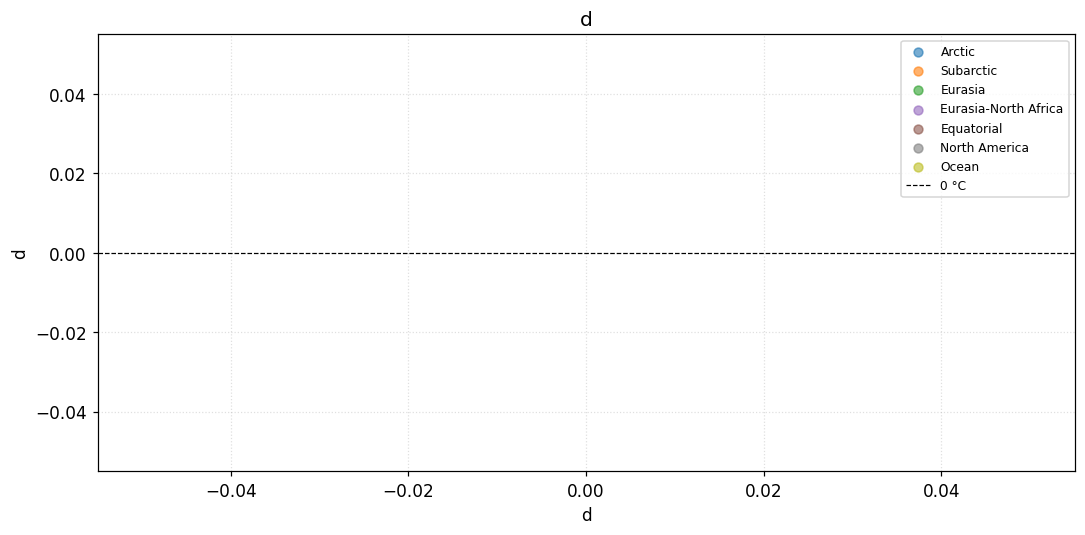

Figure 1 saved.


In [50]:
# Assign a colour to each unique zone
zones      = df['Zone'].unique()
cmap       = plt.get_cmap('tab10')
zone_color = {z: cmap(i / len(zones)) for i, z in enumerate(zones)}

fig, ax = plt.subplots(figsize=(10, 5))

# ── FILL IN: loop over zones and scatter each one ─────────────────────────
# For each zone, select the subset of df where df['Zone'] == zone,
# then call ax.scatter() with Lat_num on x, Annual_Mean on y.
# Use the colour from zone_color[zone] and add a label= so the legend works.

for zone in zones:
    subset = df[df['Zone'] == '____']
    ax.scatter(
        subset['Lat_num'],          # x: latitude
        subset['Annual_Mean'],          # y: annual mean temperature
        s=15, alpha=0.6,
        color=zone_color[zone],
        label=zone
    )

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='0 °C')
ax.legend(fontsize=8, loc='upper right', markerscale=1.5)

# ── FILL IN: axis labels and title ────────────────────────────────────────
ax.set_xlabel('d')
ax.set_ylabel('d')
ax.set_title('d')

ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('fig1_scatter_all_stations.png', dpi=150)
plt.show()
print('Figure 1 saved.')

<details><summary>💡 Hint</summary>

```python
for zone in zones:
    subset = df[df['Zone'] == zone]
    ax.scatter(subset['Lat_num'], subset['Annual_Mean'],
               s=15, alpha=0.6, color=zone_color[zone], label=zone)

ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Annual Mean Temperature (°C)')
ax.set_title('Annual Mean Temperature vs. Latitude — All Stations')
```
</details>

---
## Part 4 — Figure 2: 5-Degree Latitude Bin Averages

Grouping stations into **5° latitude bins** smooths out station-level variability  
and reveals the large-scale latitudinal temperature gradient more clearly.

### 4a — Create the bins

In [51]:
# Build bin edges that span the full latitude range in 5-degree steps
lat_min   = np.floor(df['Lat_num'].min() / 5) * 5
lat_max   = np.ceil( df['Lat_num'].max() / 5) * 5
bin_edges = np.arange(lat_min, lat_max + 5, 5)

print('Latitude range: {:.0f}° to {:.0f}°'.format(lat_min, lat_max))
print('Number of bins:', len(bin_edges) - 1)

# Assign each station to a bin
df['Lat_bin'] = pd.cut(df['Lat_num'], bins=bin_edges)

Latitude range: -90° to 85°
Number of bins: 35


In [52]:
df.head(5)

,Zone,Zone_Range,Station,Lat,Lon,Lat_num,Lon_num,Elev,Jan,Feb,...,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual_Mean,Lat_bin
0,Arctic,,10050,78.1N,13.6E,78.1,13.6,9.0,-12.3,-13.4,...,-3.7,1.9,5.1,4.6,0.8,-4.2,-8.2,-10.5,-5.416667,"(75.0, 80.0]"
1,Arctic,,200460,80.6N,58.1E,80.6,58.1,20.0,-25.0,-25.3,...,-9.1,-1.5,0.8,-0.1,-3.2,-11.8,-19.3,-23.3,-13.541667,"(80.0, 85.0]"
2,Arctic,,206740,73.5N,80.2E,73.5,80.2,20.0,-25.4,-25.5,...,-8.0,0.3,4.6,5.0,1.5,-7.5,-17.6,-22.3,-11.375000,"(70.0, 75.0]"
3,Arctic,,202920,77.7N,104.3E,77.7,104.3,13.0,-29.0,-29.4,...,-10.9,-1.5,1.4,0.6,-2.6,-13.2,-22.4,-26.2,-15.216667,"(75.0, 80.0]"
4,Arctic,,214320,76.0N,137.9E,76.0,137.9,10.0,-30.2,-30.7,...,-9.3,-0.1,2.5,1.7,-1.7,-12.3,-23.0,-27.6,-14.991667,"(75.0, 80.0]"


### 4b — Compute bin averages

Use `.groupby()` to group by latitude bin, then `.mean()` to average within each group.

In [53]:
# Group by Lat_bin and compute mean annual temperature
# FILL IN the column name to average
binned = df.groupby('Lat_bin', observed=True)['Annual_Mean'].mean().reset_index()
binned.columns = ['Lat_bin', 'Bin_Mean_Temp']

# Midpoint latitude for each bin (for plotting on a numeric axis)
binned['Lat_mid'] = binned['Lat_bin'].apply(lambda b: b.mid)

# Count stations per bin
counts = df.groupby('Lat_bin', observed=True).size().reset_index(name='N_stations')
binned = binned.merge(counts, on='Lat_bin')

print(binned.to_string(index=False))

       Lat_bin  Bin_Mean_Temp Lat_mid  N_stations
(-85.0, -80.0]     -27.891667   -82.5           1
(-80.0, -75.0]     -28.241667   -77.5           4
(-75.0, -70.0]     -13.629167   -72.5           2
(-70.0, -65.0]     -10.247917   -67.5           8
(-65.0, -60.0]      -3.465000   -62.5           5
(-55.0, -50.0]       5.744792   -52.5           8
(-50.0, -45.0]       6.179167   -47.5           4
(-45.0, -40.0]      11.550000   -42.5           8
(-40.0, -35.0]      14.541667   -37.5           6
(-35.0, -30.0]      17.611111   -32.5           9
(-30.0, -25.0]      20.002083   -27.5          12
(-25.0, -20.0]      20.380769   -22.5          13
(-20.0, -15.0]      19.891026   -17.5          13
(-15.0, -10.0]      23.475758   -12.5          11
 (-10.0, -5.0]      25.846667    -7.5          10
   (-5.0, 0.0]      25.095833    -2.5          16
    (0.0, 5.0]      23.997917     2.5           8
   (5.0, 10.0]      25.000000     7.5          11
  (10.0, 15.0]      26.270556    12.5          15


<details><summary>💡 Hint</summary>

```python
binned = df.groupby('Lat_bin', observed=True)['Annual_Mean'].mean().reset_index()
```
</details>

### 4c — Plot the binned averages

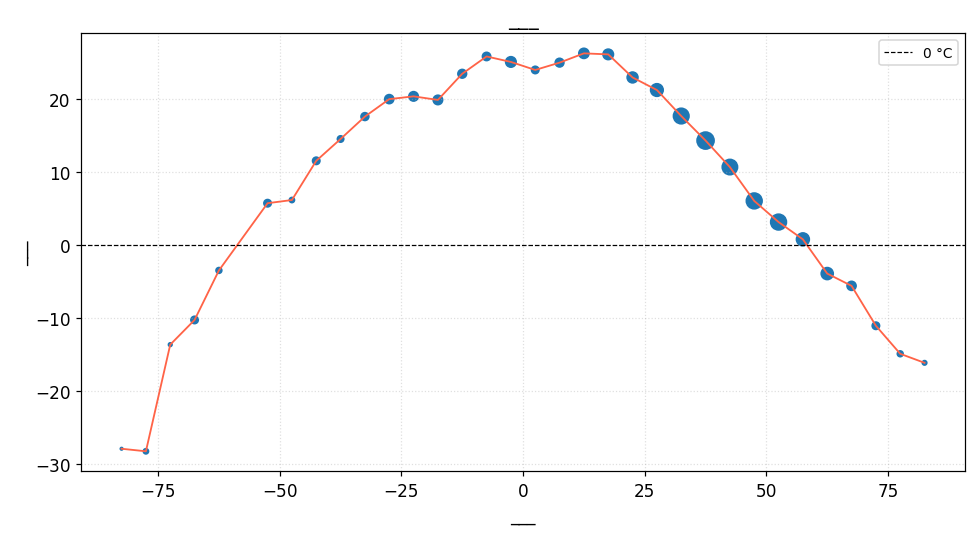

Figure 2 saved.


In [54]:
fig, ax = plt.subplots(figsize=(9, 5))

# ── FILL IN: plot binned averages ─────────────────────────────────────────
# x: Lat_mid   y: Bin_Mean_Temp
# You can use ax.scatter(), ax.plot(), or both.
# Tip: set s=binned['N_stations']*3 to size markers by station count.

ax.scatter(binned['Lat_mid'], binned['Bin_Mean_Temp'], s=binned['N_stations']*3)   # ← replace with your plot call(s)
ax.plot(binned['Lat_mid'], binned['Bin_Mean_Temp'], color='tomato', linewidth=1.2, zorder=2)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--', label='0 °C')
ax.legend(fontsize=9)

# ── FILL IN: labels and title ─────────────────────────────────────────────
ax.set_xlabel('___')
ax.set_ylabel('___')
ax.set_title('___')

ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('fig2_binned_averages.png', dpi=150)
plt.show()
print('Figure 2 saved.')

<details><summary>💡 Hint</summary>

```python
ax.scatter(binned['Lat_mid'], binned['Bin_Mean_Temp'],
           s=binned['N_stations']*3, color='tomato',
           edgecolors='darkred', linewidths=0.5, zorder=3)
ax.plot(binned['Lat_mid'], binned['Bin_Mean_Temp'],
        color='tomato', linewidth=1.2, zorder=2)
ax.set_xlabel('Latitude (°)')
ax.set_ylabel('Mean Temperature (°C)')
ax.set_title('Annual Mean Temperature — 5° Latitude Bin Averages\n(marker size ∝ station count)')
```
</details>

---
## Part 5 — Side-by-Side Comparison (Bonus / Optional)

Run this cell to see both figures next to each other — no fill-ins needed.

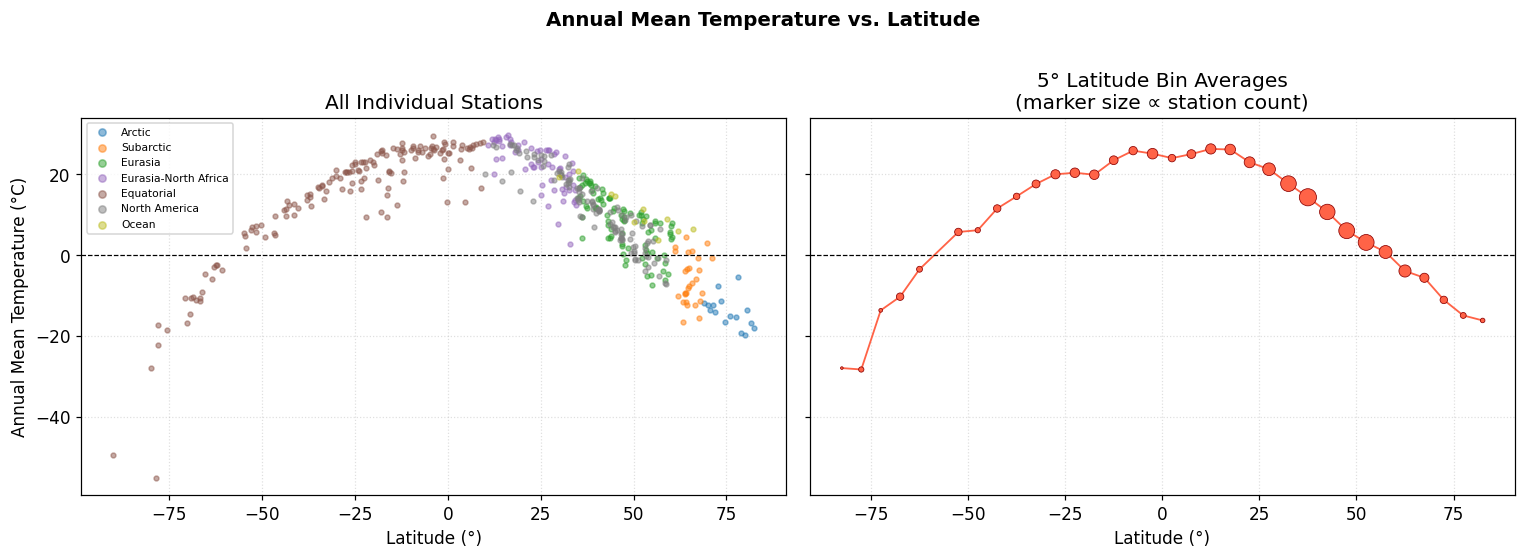

Comparison figure saved.


In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left — all stations, coloured by zone
for zone in zones:
    s = df[df['Zone'] == zone]
    axes[0].scatter(s['Lat_num'], s['Annual_Mean'],
                    s=10, alpha=0.5, color=zone_color[zone], label=zone)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Latitude (°)')
axes[0].set_ylabel('Annual Mean Temperature (°C)')
axes[0].set_title('All Individual Stations')
axes[0].legend(fontsize=7, markerscale=1.5)
axes[0].grid(True, linestyle=':', alpha=0.4)

# Right — binned averages
axes[1].scatter(binned['Lat_mid'], binned['Bin_Mean_Temp'],
                s=binned['N_stations']*3, color='tomato',
                edgecolors='darkred', linewidths=0.5, zorder=3)
axes[1].plot(binned['Lat_mid'], binned['Bin_Mean_Temp'],
             color='tomato', linewidth=1.2, zorder=2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Latitude (°)')
axes[1].set_title('5° Latitude Bin Averages\n(marker size ∝ station count)')
axes[1].grid(True, linestyle=':', alpha=0.4)

fig.suptitle('Annual Mean Temperature vs. Latitude', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Comparison figure saved.')

---
## Part 6 — Discussion Questions

Answer each question in the cell below it (2–4 sentences each).

### Q1 — General trend

Describe the overall relationship between latitude and annual mean temperature in Figure 1. Is it what you expected based on your knowledge of Earth's energy balance?

**Your answer here:**


### Q2 — Scatter vs. binned

Compare Figure 1 (all stations) and Figure 2 (binned averages). What information is visible in Figure 1 that is hidden in Figure 2, and vice versa?

**Your answer here:**


### Q3 — Role of climate zones

Look at Figure 1 with the zone colours. Do stations within the same zone cluster together in temperature-latitude space? Are there zones that overlap in latitude but differ in temperature? Suggest a physical reason.

**Your answer here:**


### Q4 — Outliers and variability

In Figure 1, stations at the same latitude can have quite different annual mean temperatures. List **at least two physical factors** that could explain this station-to-station variability.

**Your answer here:**


### Q5 — The 0 °C boundary

The dashed 0 °C line is shown on both figures. Approximately what latitude range marks the transition from below-freezing to above-freezing annual means? What ecological or climatological significance does this boundary have?

**Your answer here:**


---
## Submission Checklist

Before uploading to Canvas, confirm that you have:

- [ ] Filled in all `???` blanks and run every code cell without errors
- [ ] Figure 1 is a scatter plot of all individual stations, coloured by zone
- [ ] Figure 2 shows the 5° latitude binned averages
- [ ] All five discussion questions are answered
- [ ] Uploaded **this notebook (.ipynb)** and your **Excel file** to the Canvas assignment

---
*Lab developed for ATMS/ENSC Introduction to Meteorology & Climate*